## Fig. 1c

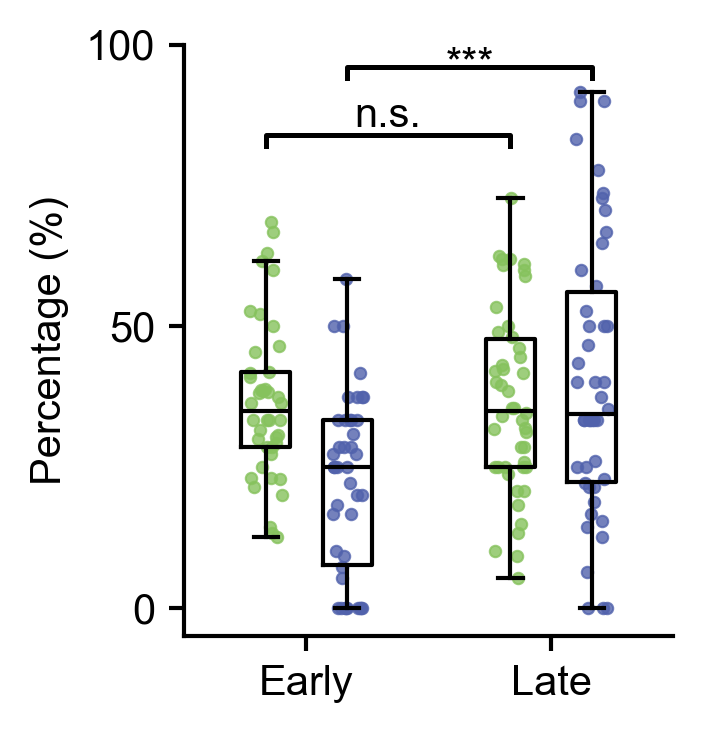

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../Results4Plots/percentage_VR.csv')
df = df.copy()
df["Animal"] = df["Animal"].astype("category")
df["Stage"] = pd.Categorical(df["Stage"], categories=["early", "late"], ordered=True)
df["CellType"] = pd.Categorical(df["CellType"], categories=["PC", "GC"], ordered=True)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Animal", "Stage", "CellType", "Value"]).copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.2, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        c = cellColor[ct]

        ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=c, edgecolors=c, linewidths=0.5, alpha=0.8, zorder=3)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Percentage (%)", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

def add_sig_bar(ax, x1, x2, y, h, text, text_offset=1.0):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k", clip_on=False)
    ax.text((x1 + x2) / 2, y + h + text_offset, text, ha="center", va="bottom", fontname="Arial", fontsize=10, clip_on=False)

add_sig_bar(ax, 1, 4, 82, 2, "n.s.", 0.01)
add_sig_bar(ax, 2, 5, 94, 2, "***", -3)

ax.set_ylim(-5, 100)
ax.set_yticks([0, 50, 100])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 1d

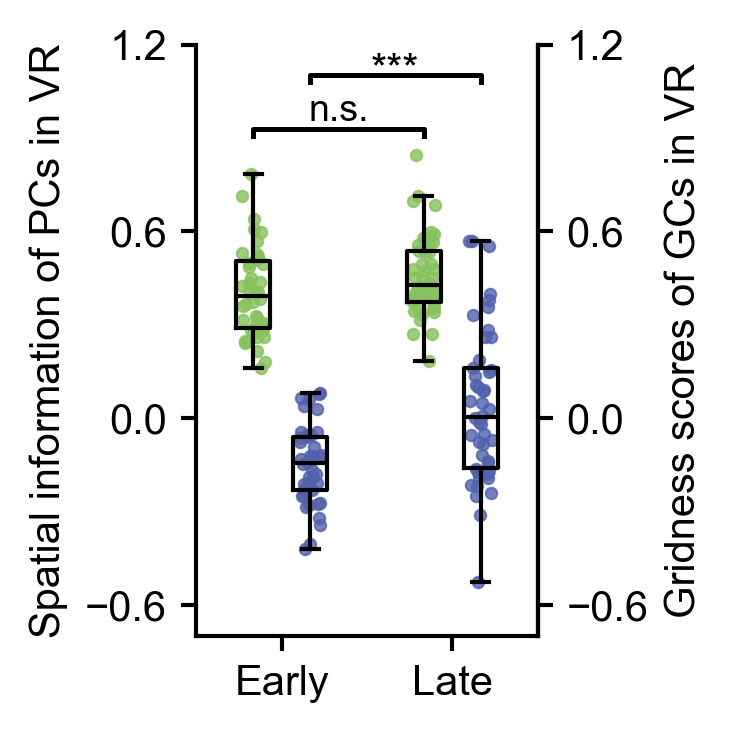

In [ ]:
df = pd.read_csv('../Results4Plots/spatialinformation_gridnessscore_VR.csv')
df = df.copy()
df["Animal"] = df["Animal"].astype("category")
df["Stage"] = pd.Categorical(df["Stage"], categories=["early", "late"], ordered=True)
df["CellType"] = pd.Categorical(df["CellType"], categories=["PC", "GC"], ordered=True)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Animal", "Stage", "CellType", "Value"]).copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        c = cellColor[ct]

        ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=c, edgecolors=c, linewidths=0.5, alpha=0.8, zorder=3)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

base_top = df["Value"].max()
y_pc = base_top + gap + 0.03
y_gc = y_pc + h + 14 * text_offset - 0.06

ax.plot([1, 1, 4, 4], [y_pc, y_pc + h, y_pc + h, y_pc], lw=1.2, c="k")
ax.text(2.5, y_pc + h + text_offset - 0.01, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.plot([2, 2, 5, 5], [y_gc + 0.02, y_gc + h + 0.02, y_gc + h + 0.02, y_gc + 0.02], lw=1.2, c="k")
ax.text(3.5, y_gc + h + text_offset - 0.04, "***", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_linewidth(1)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Spatial information of PCs in VR", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ax.set_ylim(-0.7, 1.2)
ax.set_yticks([-0.6, 0.0, 0.6, 1.2])
ax.set_xlim(0, 6)

ax_r = ax.twinx()
ax_r.set_ylim(ax.get_ylim())
ax_r.set_yticks(ax.get_yticks())
ax_r.set_yticklabels([f"{tick:.1f}".replace("-", "−") for tick in ax.get_yticks()], fontname="Arial", fontsize=10)
ax_r.set_ylabel("Gridness scores of GCs in VR", fontsize=10, fontname="Arial")

ax_r.spines["top"].set_visible(False)
ax_r.spines["left"].set_visible(False)
ax_r.spines["bottom"].set_visible(False)
ax_r.spines["right"].set_linewidth(1)
ax_r.tick_params(axis="y", direction="out", length=3.5, width=1.0, labelsize=10)

plt.tight_layout(pad=0.2)
plt.show()

## Fig. 1e

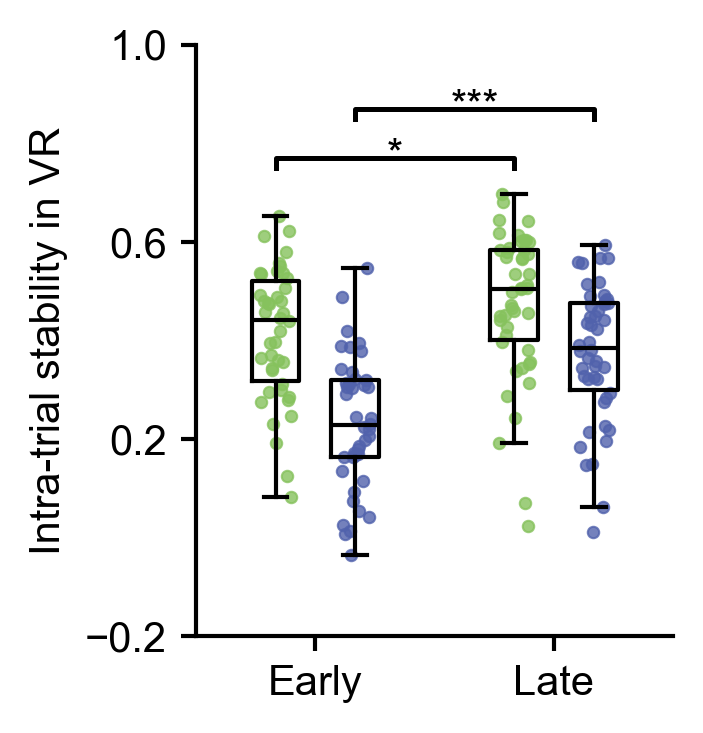

In [3]:
df = pd.read_csv('../Results4Plots/intertrial_stability_VR.csv')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()
df["Animal"] = df["Animal"].astype("category")
df["Stage"] = pd.Categorical(df["Stage"], categories=["early", "late"], ordered=True)
df["CellType"] = pd.Categorical(df["CellType"], categories=["PC", "GC"], ordered=True)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Animal", "Stage", "CellType", "Value"]).copy()

stage_levels = ["early", "late"]
cell_types = ["PC", "GC"]

colorPC = np.array([134, 194, 93]) / 255.0
colorGC = np.array([81, 98, 172]) / 255.0
cellColor = {"PC": colorPC, "GC": colorGC}

xpos = {
    ("early", "PC"): 1,
    ("early", "GC"): 2,
    ("late", "PC"): 4,
    ("late", "GC"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2.2, 2.3), dpi=300)

for st in stage_levels:
    for ct in cell_types:
        sub = df[(df["Stage"] == st) & (df["CellType"] == ct)]
        y = sub["Value"].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(st, ct)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width
        c = cellColor[ct]

        ax.scatter(x0 + jitter, y, s=7.5, marker="o", facecolors=c, edgecolors=c, linewidths=0.5, alpha=0.8, zorder=3)

        bp = ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

        for k in ["boxes", "medians", "whiskers", "caps"]:
            for artist in bp[k]:
                artist.set_zorder(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for item in ax.get_yticklabels():
    item.set_fontname("Arial")

ax.set_ylabel("Intra-trial stability in VR", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

def add_sig_bar(ax, x1, x2, y, h, text, text_offset):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="k", clip_on=False)
    ax.text((x1 + x2) / 2, y + h + text_offset, text, ha="center", va="bottom", fontname="Arial", fontsize=10, clip_on=False)

add_sig_bar(ax, 1, 4, 0.75, 0.02, "*", -0.035)
add_sig_bar(ax, 2, 5, 0.85, 0.02, "***", -0.035)

ax.set_ylim(-0.2, 1.0)
ax.set_yticks([-0.2, 0.2, 0.6, 1.0])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()